In [3]:
!pip install catboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

Saving fetal_health.csv to fetal_health.csv


In [6]:
df = pd.read_csv("fetal_health.csv")
df.head()


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0


In [7]:
X = df.drop("fetal_health", axis=1)
y = df["fetal_health"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
models = {
    "RF": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "DT": DecisionTreeClassifier(),
    "SVM": SVC(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [9]:

def evaluate_models(X_tr, X_te, y_tr, y_te):
    results = {}

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)

        results[name] = [
            accuracy_score(y_te, y_pred),
            precision_score(y_te, y_pred, average='weighted'),
            recall_score(y_te, y_pred, average='weighted'),
            f1_score(y_te, y_pred, average='weighted')
        ]

    return pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1"]).T

In [10]:
print("\n📊 TABLE 1: WITHOUT FEATURE SELECTION")

df_no_fs = evaluate_models(X_train, X_test, y_train - 1, y_test - 1)
print(df_no_fs)


📊 TABLE 1: WITHOUT FEATURE SELECTION


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:55:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          Accuracy  Precision    Recall        F1
RF        0.948357   0.947411  0.948357  0.947726
KNN       0.915493   0.912144  0.915493  0.912794
DT        0.927230   0.930079  0.927230  0.928309
SVM       0.903756   0.904599  0.903756  0.903630
XGBoost   0.960094   0.959859  0.960094  0.959967
CatBoost  0.962441   0.962004  0.962441  0.962050


In [11]:

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier

feature_sizes = list(range(2, 22))

mi_acc = []
anova_acc = []
cc_acc = []

# Correlation computed once
corr = df.corr()["fetal_health"].abs().sort_values(ascending=False)[1:]

for k in feature_sizes:

    model = CatBoostClassifier(verbose=0, random_state=42)

    # 🔹 MUTUAL INFORMATION
    selector_mi = SelectKBest(mutual_info_classif, k=k)
    X_train_mi = selector_mi.fit_transform(X_train, y_train - 1)
    X_test_mi = selector_mi.transform(X_test)

    model.fit(X_train_mi, y_train - 1)
    y_pred_mi = model.predict(X_test_mi)
    mi_acc.append(accuracy_score(y_test - 1, y_pred_mi))


    # 🔹 ANOVA
    selector_anova = SelectKBest(f_classif, k=k)
    X_train_anova = selector_anova.fit_transform(X_train, y_train - 1)
    X_test_anova = selector_anova.transform(X_test)

    model.fit(X_train_anova, y_train - 1)
    y_pred_anova = model.predict(X_test_anova)
    anova_acc.append(accuracy_score(y_test - 1, y_pred_anova))


    # 🔹 CORRELATION (FIXED PART ✅)
    top_features = corr.index[:k]

    X_train_cc = pd.DataFrame(X_train, columns=df.columns[:-1])[top_features]
    X_test_cc = pd.DataFrame(X_test, columns=df.columns[:-1])[top_features]

    model.fit(X_train_cc, y_train - 1)
    y_pred_cc = model.predict(X_test_cc)
    cc_acc.append(accuracy_score(y_test - 1, y_pred_cc))


print("mi_acc:", mi_acc)
print("anova_acc:", anova_acc)
print("cc_acc:", cc_acc)
print("feature_sizes:", feature_sizes)

mi_acc: [0.8591549295774648, 0.9061032863849765, 0.9577464788732394, 0.9507042253521126, 0.9436619718309859, 0.9553990610328639, 0.9507042253521126, 0.9553990610328639, 0.9553990610328639, 0.9553990610328639, 0.9507042253521126, 0.9553990610328639, 0.960093896713615, 0.960093896713615, 0.960093896713615, 0.9647887323943662, 0.9624413145539906, 0.9647887323943662, 0.960093896713615, 0.9530516431924883]
anova_acc: [0.8286384976525821, 0.9084507042253521, 0.9413145539906104, 0.9460093896713615, 0.9507042253521126, 0.9436619718309859, 0.9483568075117371, 0.9577464788732394, 0.9553990610328639, 0.9647887323943662, 0.9624413145539906, 0.960093896713615, 0.9671361502347418, 0.9624413145539906, 0.9553990610328639, 0.9577464788732394, 0.960093896713615, 0.9624413145539906, 0.9624413145539906, 0.9530516431924883]
cc_acc: [0.8286384976525821, 0.9084507042253521, 0.9061032863849765, 0.9413145539906104, 0.9413145539906104, 0.9389671361502347, 0.9530516431924883, 0.9553990610328639, 0.95539906103286

In [12]:
table2 = pd.DataFrame({
    "MI": mi_acc,
    "ANOVA": anova_acc,
    "CC": cc_acc
}, index=feature_sizes)

table2.index.name = "Feature set size"

table2 = table2.round(2)

print("\n📊 TABLE 2 (FINAL - PAPER STYLE)")
print(table2.to_string())


📊 TABLE 2 (FINAL - PAPER STYLE)
                    MI  ANOVA    CC
Feature set size                   
2                 0.86   0.83  0.83
3                 0.91   0.91  0.91
4                 0.96   0.94  0.91
5                 0.95   0.95  0.94
6                 0.94   0.95  0.94
7                 0.96   0.94  0.94
8                 0.95   0.95  0.95
9                 0.96   0.96  0.96
10                0.96   0.96  0.96
11                0.96   0.96  0.96
12                0.95   0.96  0.95
13                0.96   0.96  0.96
14                0.96   0.97  0.96
15                0.96   0.96  0.97
16                0.96   0.96  0.97
17                0.96   0.96  0.97
18                0.96   0.96  0.96
19                0.96   0.96  0.97
20                0.96   0.96  0.96
21                0.95   0.95  0.96


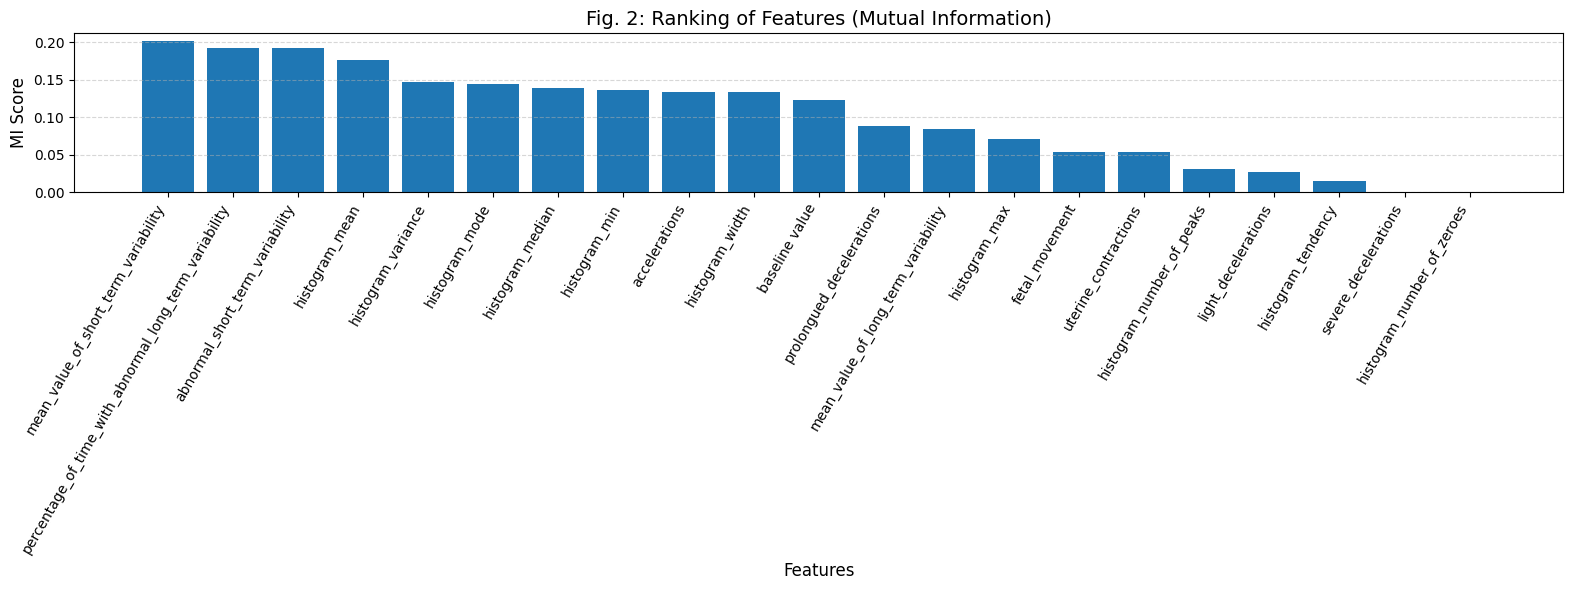

In [13]:
from sklearn.feature_selection import mutual_info_classif

# Compute MI scores
mi_scores = mutual_info_classif(X, y)

# Create DataFrame
mi_df = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Score": mi_scores
})

# Sort features
mi_df = mi_df.sort_values(by="Score", ascending=False)

# 🔥 BIGGER + CLEANER PLOT (PAPER STYLE)
plt.figure(figsize=(16,6))  # wider like paper

bars = plt.bar(mi_df["Feature"], mi_df["Score"])

plt.title("Fig. 2: Ranking of Features (Mutual Information)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("MI Score", fontsize=12)

plt.xticks(rotation=60, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

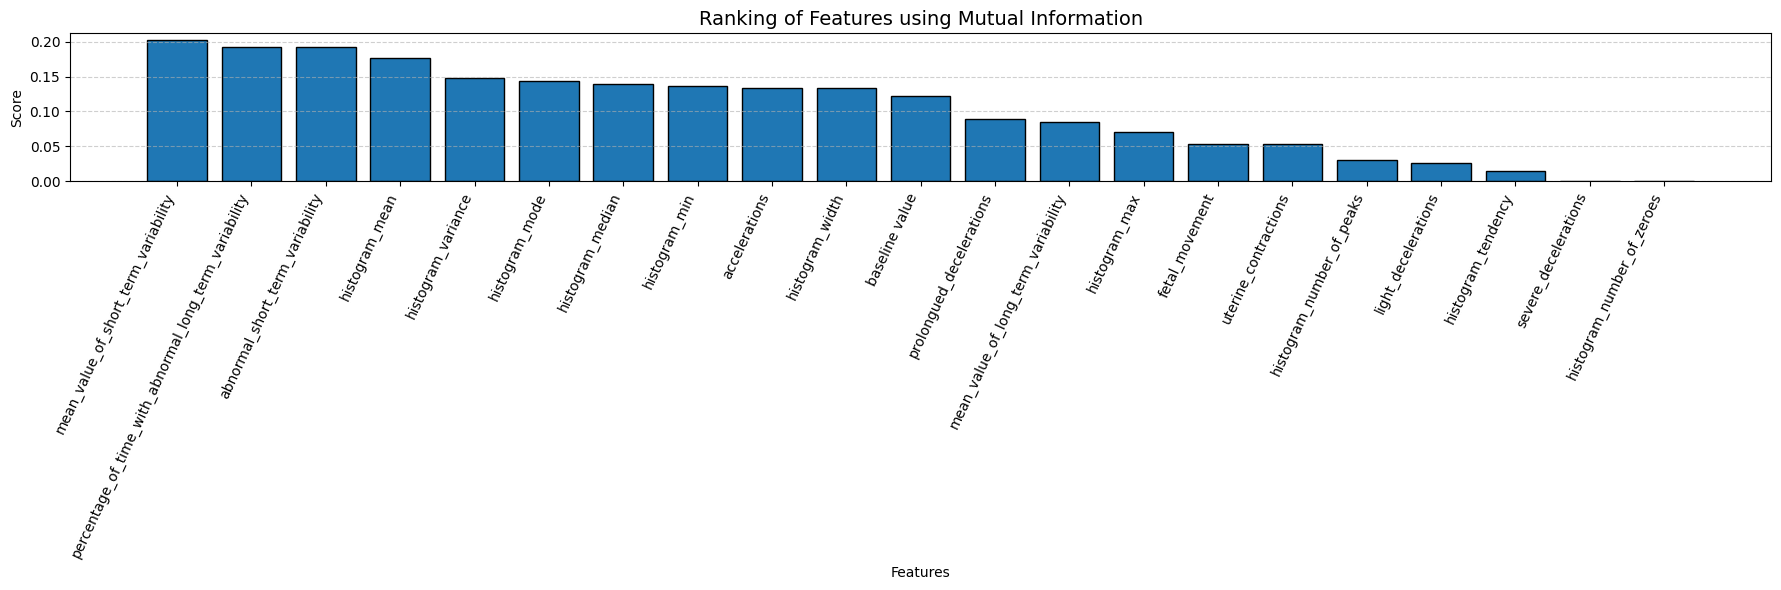

In [14]:
plt.figure(figsize=(18,6))

plt.bar(mi_df["Feature"], mi_df["Score"], edgecolor='black')

plt.title("Ranking of Features using Mutual Information", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Score")

plt.xticks(rotation=65, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

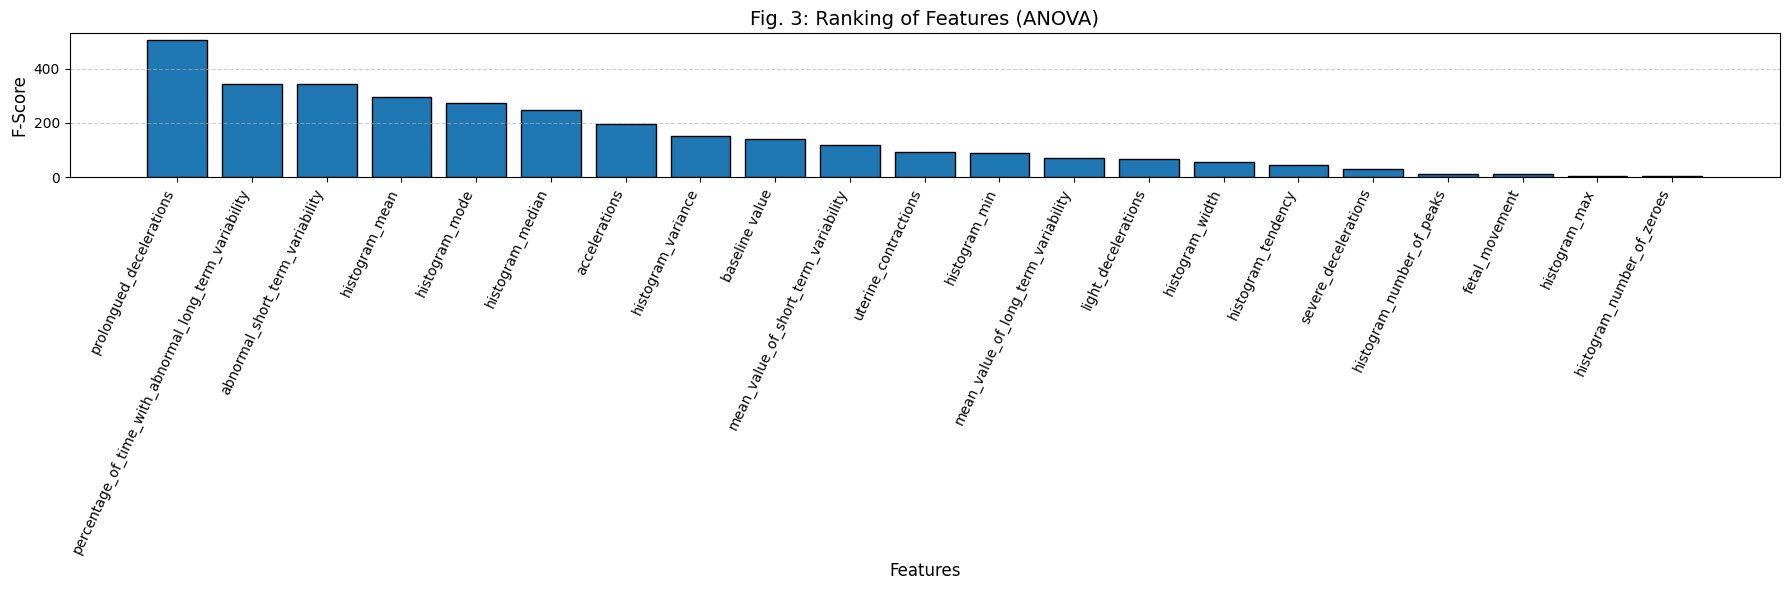

In [15]:
from sklearn.feature_selection import f_classif

# Compute ANOVA scores
anova_scores, _ = f_classif(X, y)

# Create DataFrame
anova_df = pd.DataFrame({
    "Feature": df.columns[:-1],
    "Score": anova_scores
})

# Sort features (descending)
anova_df = anova_df.sort_values(by="Score", ascending=False)

# 🔥 PLOT (MATCH FIG 2 STYLE)
plt.figure(figsize=(18,6))

plt.bar(anova_df["Feature"], anova_df["Score"], edgecolor='black')

plt.title("Fig. 3: Ranking of Features (ANOVA)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("F-Score", fontsize=12)

plt.xticks(rotation=65, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

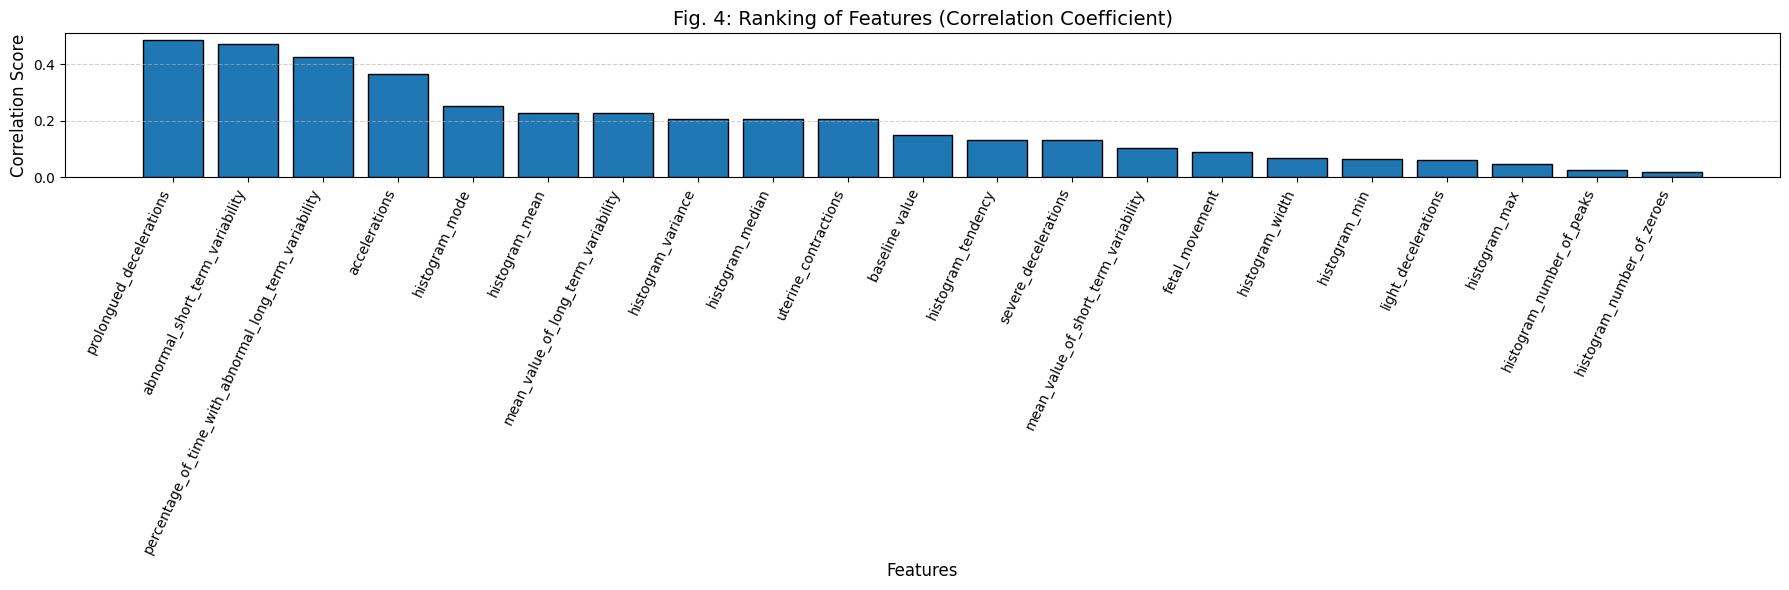

In [16]:
# Compute correlation with target
corr_values = df.corr()["fetal_health"].drop("fetal_health")

# Take absolute values (important!)
corr_values = corr_values.abs()

# Convert to DataFrame
corr_df = corr_values.sort_values(ascending=False).reset_index()
corr_df.columns = ["Feature", "Score"]

# 🔥 PLOT (MATCH FIG 2 & 3 STYLE)
plt.figure(figsize=(18,6))

plt.bar(corr_df["Feature"], corr_df["Score"], edgecolor='black')

plt.title("Fig. 4: Ranking of Features (Correlation Coefficient)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Correlation Score", fontsize=12)

plt.xticks(rotation=65, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

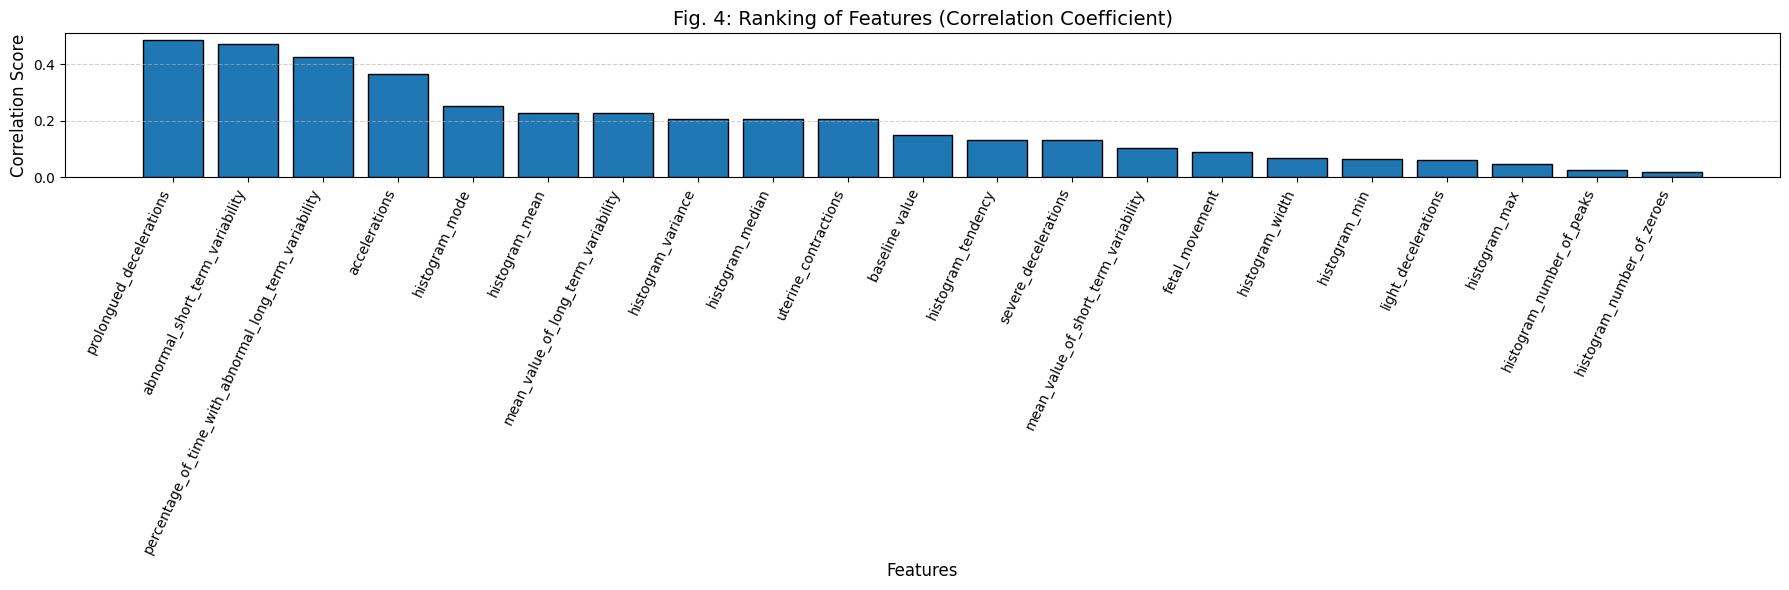

In [17]:
# Compute correlation with target
corr_values = df.corr()["fetal_health"].drop("fetal_health")

# Take absolute values (important!)
corr_values = corr_values.abs()

# Convert to DataFrame
corr_df = corr_values.sort_values(ascending=False).reset_index()
corr_df.columns = ["Feature", "Score"]

# 🔥 PLOT (MATCH FIG 2 & 3 STYLE)
plt.figure(figsize=(18,6))

plt.bar(corr_df["Feature"], corr_df["Score"], edgecolor='black')

plt.title("Fig. 4: Ranking of Features (Correlation Coefficient)", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Correlation Score", fontsize=12)

plt.xticks(rotation=65, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif

anova = SelectKBest(f_classif, k=14)
X_best = anova.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_best, y, test_size=0.2, random_state=42
)

model = CatBoostClassifier(verbose=0, random_state=42)
model.fit(X_train, y_train - 1)

y_pred = model.predict(X_test)

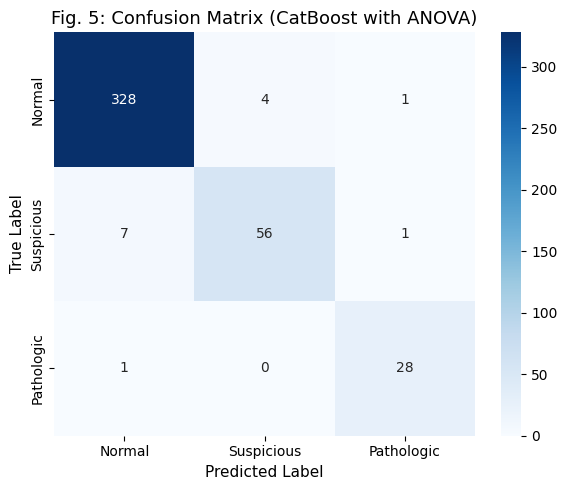

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test - 1, y_pred)

labels = ["Normal", "Suspicious", "Pathologic"]

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Fig. 5: Confusion Matrix (CatBoost with ANOVA)", fontsize=13)
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
model_all = CatBoostClassifier(verbose=0, random_state=42)

# Using the full training and testing datasets (X_train, X_test) that were previously defined
model_all.fit(X_train, y_train - 1)
y_pred_all = model_all.predict(X_test)

In [21]:
# Already done earlier, just reuse if available

model_14 = CatBoostClassifier(verbose=0, random_state=42)
model_14.fit(X_train, y_train - 1)
y_pred_14 = model_14.predict(X_test)

In [22]:
from sklearn.metrics import precision_recall_fscore_support

# All features
prec_all, rec_all, f1_all, _ = precision_recall_fscore_support(
    y_test - 1, y_pred_all
)

# 14 features
prec_14, rec_14, f1_14, _ = precision_recall_fscore_support(
    y_test - 1, y_pred_14
)

In [23]:
classes = ["Normal (1)", "Suspicious (2)", "Pathologic (3)"]

table3 = pd.DataFrame({
    "Class value": classes,

    "Precision (all features)": prec_all,
    "Precision (14 features)": prec_14,

    "Recall (all features)": rec_all,
    "Recall (14 features)": rec_14,

    "F1-score (all features)": f1_all,
    "F1-score (14 features)": f1_14
})

table3 = table3.round(2)

print("\n📊 TABLE: Class-wise Performance Comparison")
print(table3.to_string(index=False))


📊 TABLE: Class-wise Performance Comparison
   Class value  Precision (all features)  Precision (14 features)  Recall (all features)  Recall (14 features)  F1-score (all features)  F1-score (14 features)
    Normal (1)                      0.98                     0.98                   0.98                  0.98                     0.98                    0.98
Suspicious (2)                      0.93                     0.93                   0.88                  0.88                     0.90                    0.90
Pathologic (3)                      0.93                     0.93                   0.97                  0.97                     0.95                    0.95


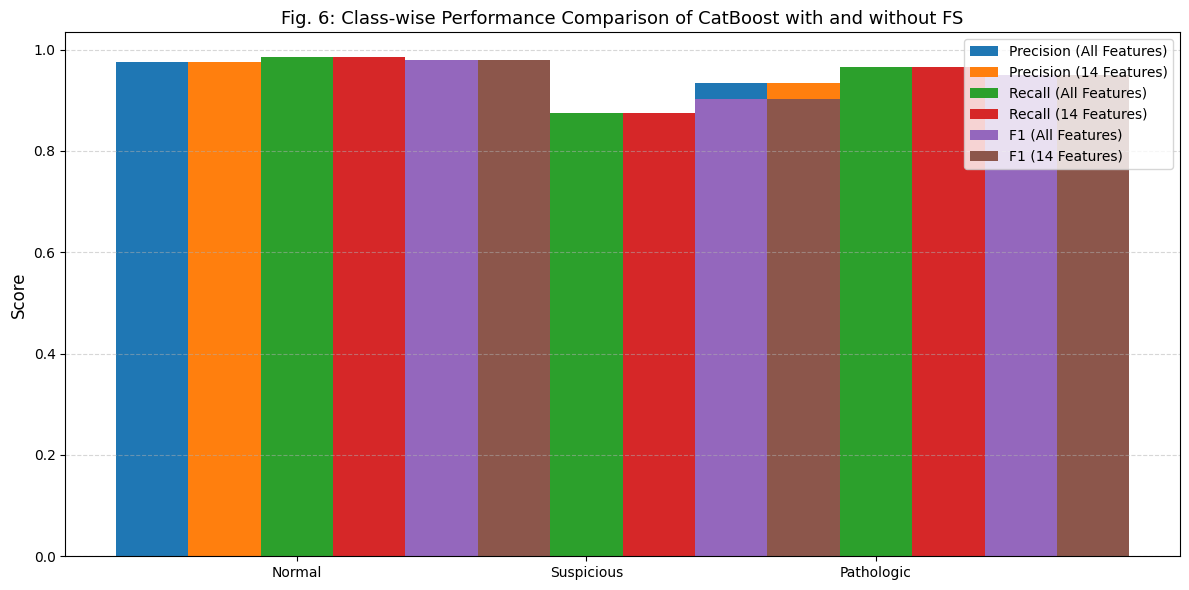

In [26]:
import numpy as np
import matplotlib.pyplot as plt

classes = ["Normal", "Suspicious", "Pathologic"]

x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(12,6))

# 🔹 Precision
plt.bar(x - width, prec_all, width, label="Precision (All Features)")
plt.bar(x, prec_14, width, label="Precision (14 Features)")

# 🔹 Recall
plt.bar(x + width, rec_all, width, label="Recall (All Features)")
plt.bar(x + 2*width, rec_14, width, label="Recall (14 Features)")

# 🔹 F1 Score (shift more)
plt.bar(x + 3*width, f1_all, width, label="F1 (All Features)")
plt.bar(x + 4*width, f1_14, width, label="F1 (14 Features)")

plt.xticks(x + width, classes)

plt.ylabel("Score", fontsize=12)
plt.title("Fig. 6: Class-wise Performance Comparison of CatBoost with and without FS", fontsize=13)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

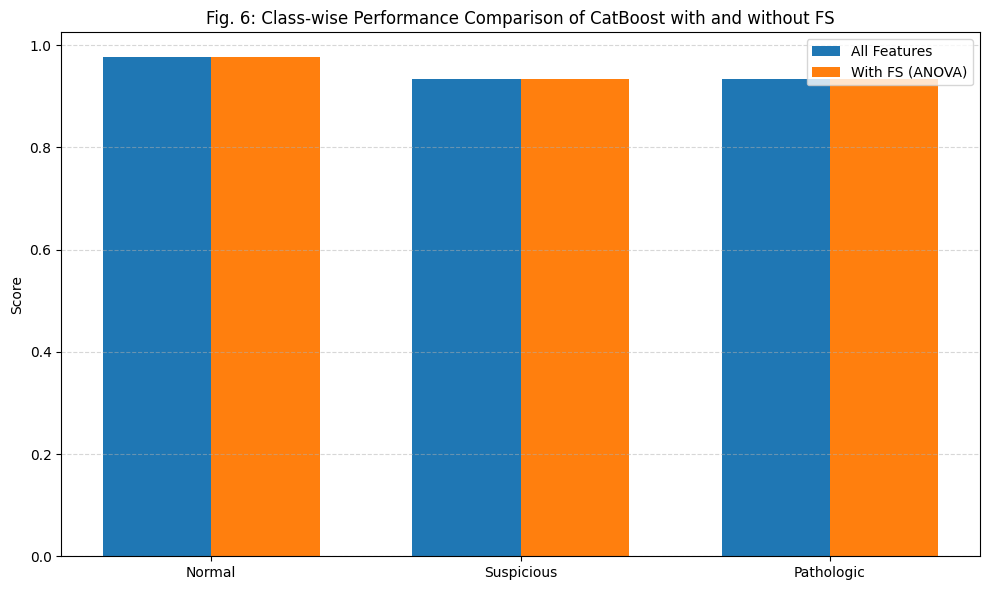

In [27]:
x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(10,6))

# Precision comparison
plt.bar(x - width/2, prec_all, width, label="All Features")
plt.bar(x + width/2, prec_14, width, label="With FS (ANOVA)")

plt.xticks(x, classes)

plt.ylabel("Score")
plt.title("Fig. 6: Class-wise Performance Comparison of CatBoost with and without FS")

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()